# **Apple Stock Price Prediction for the Next 30 Days**

**Overview:** This project predicts the future price of Apple stock using historical stock market data.
The dataset includes daily stock values like opening price, closing price, highest price, lowest price, and trading volume.

**Project Objectives:**


Understand stock price patterns over time

Analyze important factors affecting price

Find relationships between stock features

Build a model to predict future stock prices

Help in better investment decision making


# **Stage 1: Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('Apple_DATASET.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2006,2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2007,2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2008,2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300
2009,2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500
2010,2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600


In [5]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Display first 5 rows
print("DataFrame after converting 'Date' to datetime and setting as index:")
display(df.head())

DataFrame after converting 'Date' to datetime and setting as index:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(0)

# **Stage 2: EDA**

In [6]:
df.shape

(2011, 6)

In [7]:
df.size

12066

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [9]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [10]:
df.dtypes

Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

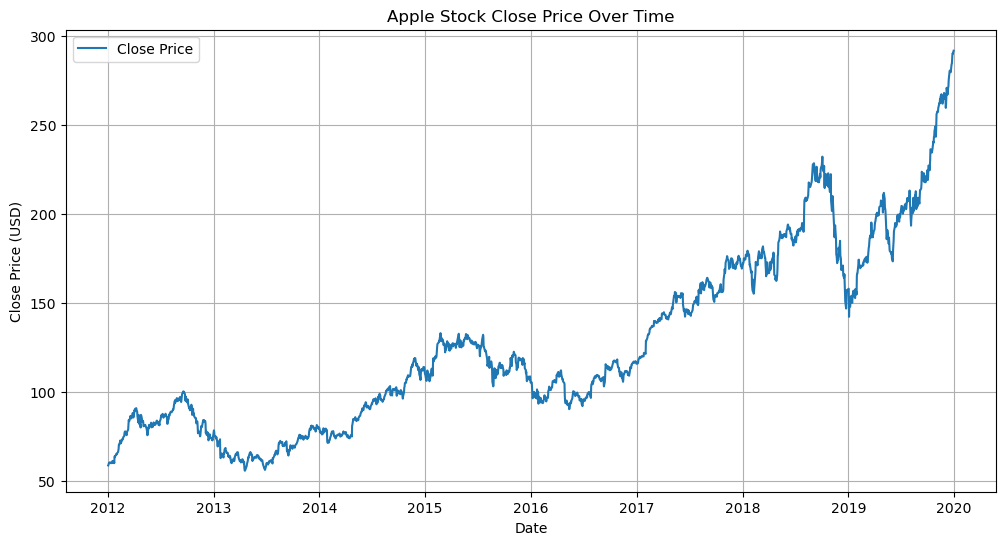

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.title('Apple Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

**Overall Trend**: The plot clearly shows the general direction of the stock price over the years. You can see periods of growth, stability, and potential downturns.

**Volatility**: Notice how much the price fluctuates daily. Areas with more jagged lines indicate higher volatility, while smoother sections suggest more stable periods.

**Significant Events**: Keep an eye out for any sudden, sharp drops or spikes that deviate significantly from the general trend. These could correspond to major news, economic events, or company-specific announcements.

**Outliers Detection:** We used return-based anomaly detection to identify unusual stock price movements and detect outliers in the time series data.

In [14]:
# Calculate daily returns
df['Return'] = df['Close'].pct_change()

In [15]:
# Calculate Z-score
mean_return = df['Return'].mean()
std_return = df['Return'].std()
df['Z_Score'] = (df['Return'] - mean_return) / std_return


In [16]:
# Detect anomalies (Z-score > 3 or < -3)
df['Anomaly'] = np.where(abs(df['Z_Score']) > 3, 1, 0)

In [17]:
# Show anomalous days
anomalies = df[df['Anomaly'] == 1]


In [18]:
print("Number of anomalies:", len(anomalies))
display(anomalies[['Close', 'Return', 'Z_Score']])

Number of anomalies: 31


,Close,Return,Z_Score
Date,,,
2012-01-25,63.808571,0.062439,3.814930
2012-04-17,87.099998,0.050971,3.103702
2012-04-25,87.142860,0.088741,5.446195
2012-05-21,80.182854,0.058260,3.555753
2012-11-19,80.818573,0.072108,4.414603
2012-12-05,76.970001,-0.064357,-4.048933
2013-01-24,64.357140,-0.123558,-7.720565
2013-04-17,57.542858,-0.054993,-3.468150
2013-07-24,62.930000,0.051362,3.127911


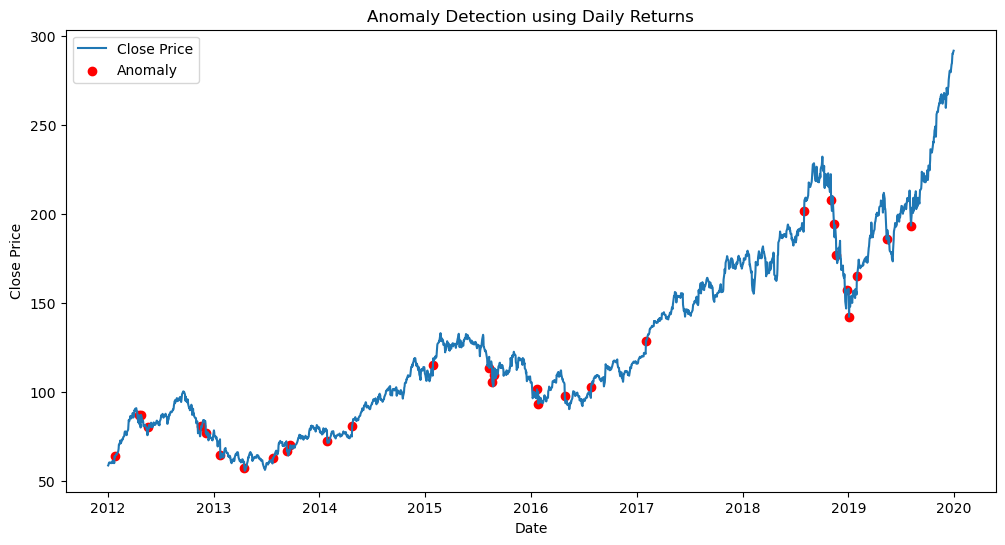

In [19]:
# Visualize outliers

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close Price')

plt.scatter(
    anomalies.index,
    anomalies['Close'],
    color='red',
    label='Anomaly'
)

plt.title('Anomaly Detection using Daily Returns')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

**Return-based anomaly detection:** It was performed using the Z-score method. A total of 31 anomalous observations were identified. Since these observations represent genuine market movements rather than data errors, they were retained in the dataset to preserve real-world stock behavior for forecasting.

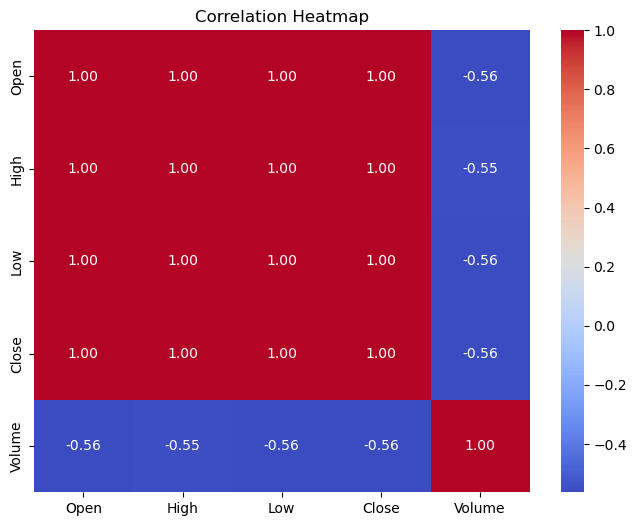

In [26]:
# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

**Result:** The heatmap shows that Open, High, Low, and Close prices are highly correlated and move together. Volume has a moderate negative correlation with stock prices.

# **Stage 3: Time Series Analysis**

**1. Trend Analysis**

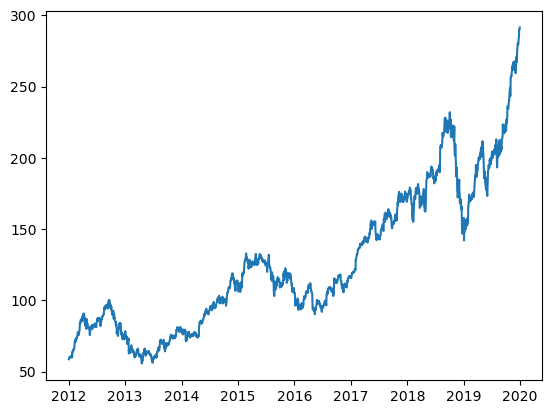

In [27]:
plt.plot(df['Close'])

The line plot of Apple's closing stock price shows a clear upward trend from 2012 to 2020, indicating long-term growth. Although short-term fluctuations and temporary declines are present, the overall movement is increasing, suggesting that the series is trend-dominated.

**2. Seasonality Analysis**

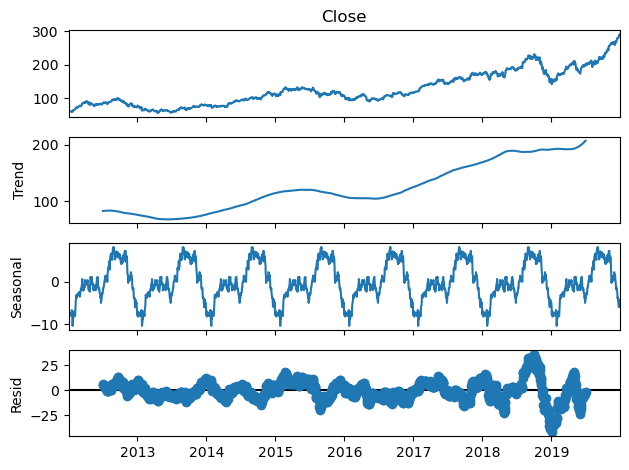

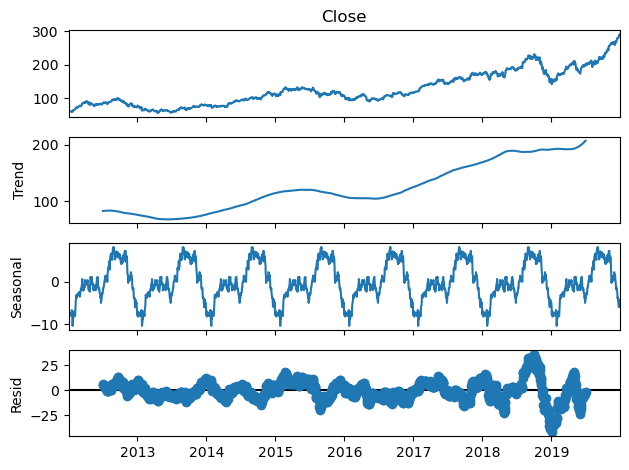

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], model='additive', period=252)

decomposition.plot()

Seasonal decomposition was performed to separate the time series into trend, seasonal, and residual components. The results indicate a strong upward trend and mild seasonal fluctuations in Apple's stock price. The presence of a clear trend suggests that the series is likely non-stationary and requires further testing using the Augmented Dickey-Fuller (ADF) test.

**3. Check Stationarity (ADF Test)**

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Not Stationary")

ADF Statistic: 1.2193701254378042
p-value: 0.996117017803201
Data is Not Stationary


**4. Apply First Differencing**

In [30]:
df['Close_Diff'] = df['Close'].diff()

In [31]:
df_diff = df['Close_Diff'].dropna()

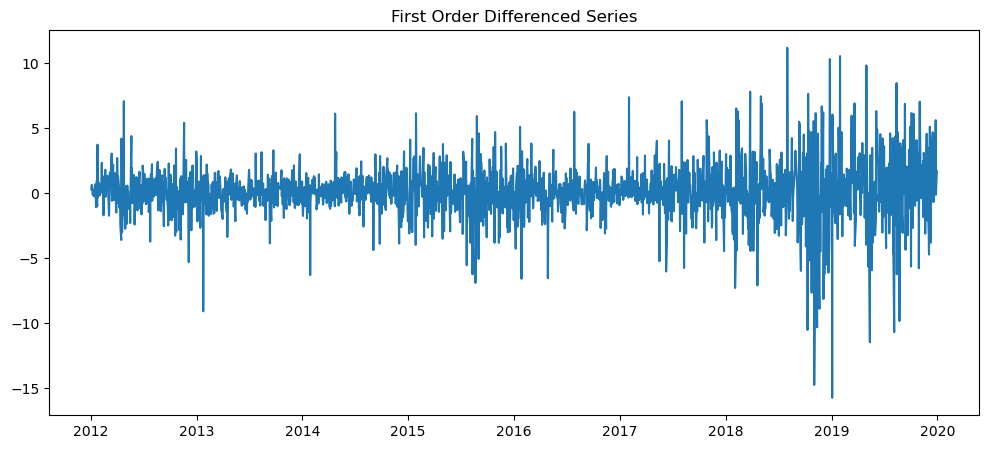

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df_diff)
plt.title("First Order Differenced Series")
plt.show()

First-order differencing was applied to remove the trend and make the time series stationary.

**5. Run ADF Test Again**

In [33]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Not Stationary")

ADF Statistic: -13.62553432387326
p-value: 1.7631231987209282e-25
Data is Stationary


**6. Plot ACF and PACF**

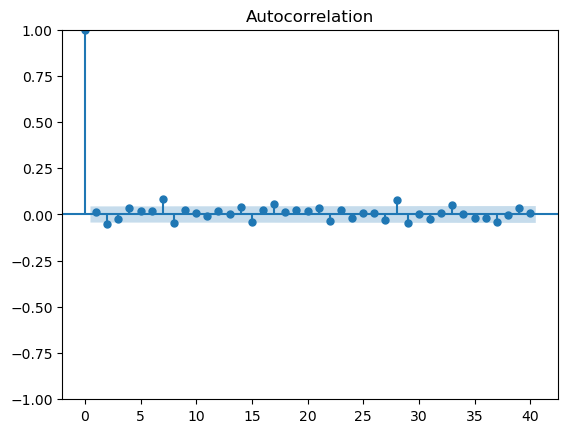

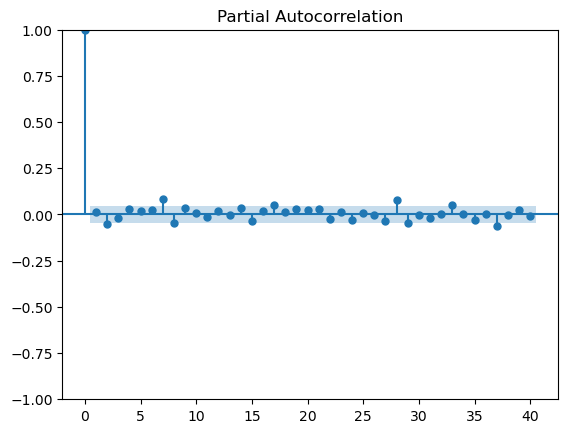

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(df_diff, lags=40)
plt.show()

plot_pacf(df_diff, lags=40)
plt.show()

The ACF and PACF plots of the differenced series show that most autocorrelation values lie within the confidence intervals, indicating that the series has become stationary after differencing. No strong autoregressive or moving average patterns are observed

# **Stage 4: Feature Engineering**

**1: Create Lag Features:** Because Previous stock prices help predict the next day's price.

In [35]:
df_ml = df.copy()

df_ml['Lag_1'] = df_ml['Close'].shift(1)
df_ml['Lag_2'] = df_ml['Close'].shift(2)
df_ml['Lag_3'] = df_ml['Close'].shift(3)
df_ml['Lag_7'] = df_ml['Close'].shift(7)

**2: Create Moving Average Features:** Because it captures short-term and long-term trends.

In [36]:
df_ml['MA_7'] = df_ml['Close'].rolling(window=7).mean()
df_ml['MA_30'] = df_ml['Close'].rolling(window=30).mean()

**3: Remove Generated NaN Values:** Because lag and moving average features create NaN values at the beginning.

In [37]:
df_ml.dropna(inplace=True)

df_ml.head()

,Open,High,Low,Close,Adj Close,Volume,Return,Z_Score,Anomaly,Close_Diff,Lag_1,Lag_2,Lag_3,Lag_7,MA_7,MA_30
Date,,,,,,,,,,,,,,,,
2012-02-14,72.094284,72.794289,71.714287,72.779999,62.892056,115099600,0.013649,0.788980,0,0.979996,71.800003,70.488571,70.452858,65.668571,69.553674,63.574667
2012-02-15,73.465714,75.184288,70.984283,71.095711,61.436600,376530000,-0.023142,-1.492800,0,-1.684288,72.779999,71.800003,70.488571,66.281425,70.241429,63.986286
2012-02-16,70.214287,72.127144,69.518570,71.744286,61.997032,236138000,0.009123,0.508253,0,0.648575,71.095711,72.779999,71.800003,66.975716,70.922653,64.409000
2012-02-17,71.872856,72.538574,71.471428,71.731430,61.985954,133951300,-0.000179,-0.068640,0,-0.012856,71.744286,71.095711,72.779999,68.097145,71.441837,64.809428
2012-02-21,72.411430,73.550003,72.017143,73.550003,63.557446,151398800,0.025353,1.514832,0,1.818573,71.731430,71.744286,71.095711,70.452858,71.884286,65.249667


**4: Define Features and Target**

In [38]:
X = df_ml[['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'MA_7', 'MA_30']]
y = df_ml['Close']

**5: Train-Test Split**

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# **Stage 5: Baseline Models**

**1. Linear Regression Model**

In [40]:
# Model building
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [44]:
# evaluating model
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("MAPE:", mape_lr)
print("R²  :", r2_lr)

MAE : 2.2816700839908624
RMSE: 3.095700653630355
MAPE: 1.1442677609679763
R²  : 0.989445671141596


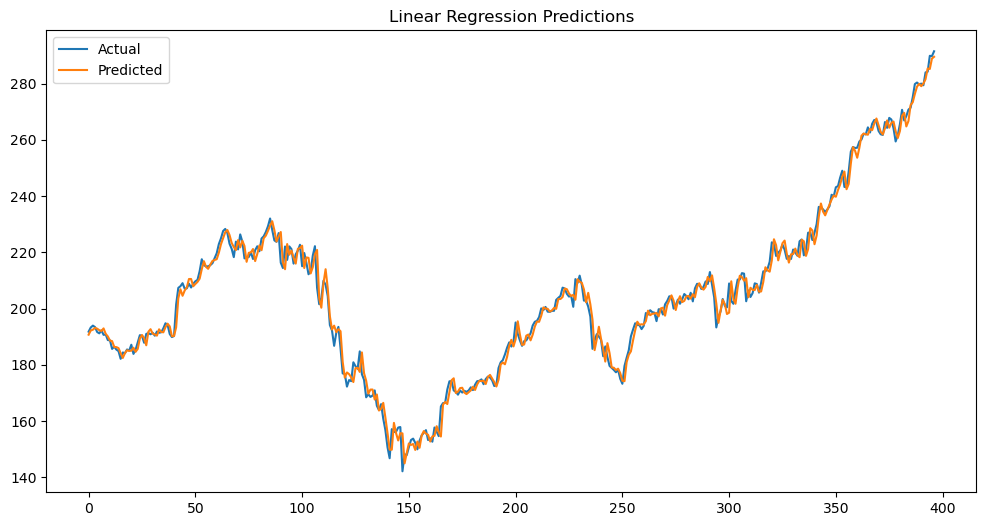

In [45]:
# plotting actual vs. predicted
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(y_pred_lr, label='Predicted')

plt.title('Linear Regression Predictions')

plt.legend()

plt.show()

**2. Random forest model**

In [46]:
# model building
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [47]:
# model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)
print("R²  :", r2_rf)

MAE : 21.52191873959709
RMSE: 32.29007454811289
MAPE: 9.258610923985852
R²  : -0.14828792955105574


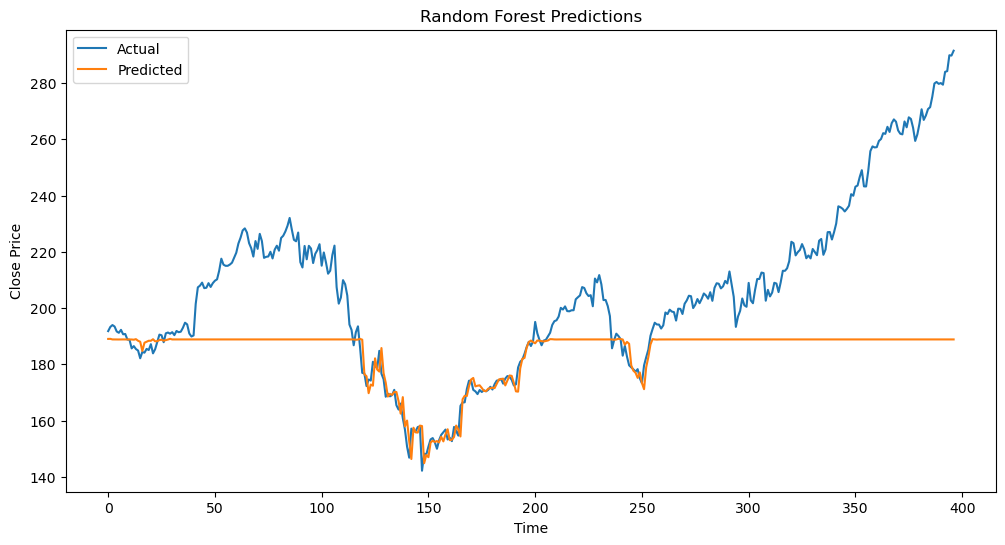

In [48]:
# plotting actual vs. predicted
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(y_pred_rf, label='Predicted')

plt.title('Random Forest Predictions')

plt.xlabel('Time')

plt.ylabel('Close Price')

plt.legend()

plt.show()

In [49]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

  Feature  Importance
0   Lag_1    0.834827
4    MA_7    0.101432
1   Lag_2    0.053571
2   Lag_3    0.009286
5   MA_30    0.000500
3   Lag_7    0.000383


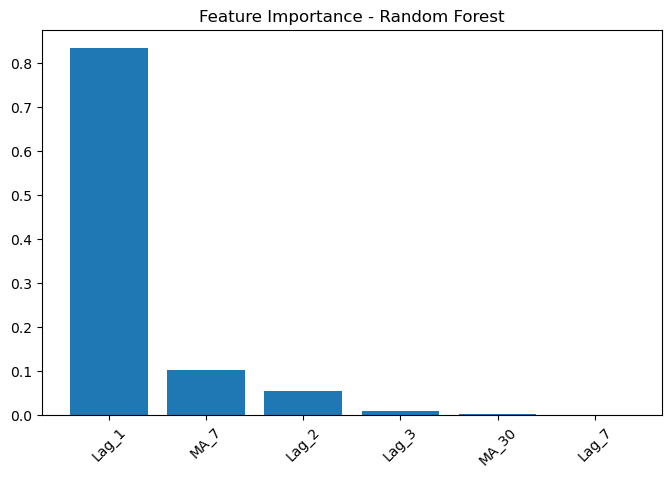

In [50]:
# Plot Feature Importance
plt.figure(figsize=(8,5))

plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.title('Feature Importance - Random Forest')

plt.xticks(rotation=45)

plt.show()

**Note:** Linear Regression outperformed Random Forest due to the strong linear trend present in the stock price series.

**3. XGBoost Model**

In [54]:
# model building
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [55]:
# Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100

r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)
print("R²  :", r2_xgb)

MAE : 22.37095641201836
RMSE: 33.046055250174454
MAPE: 9.654285627704354
R²  : -0.20268516379024537


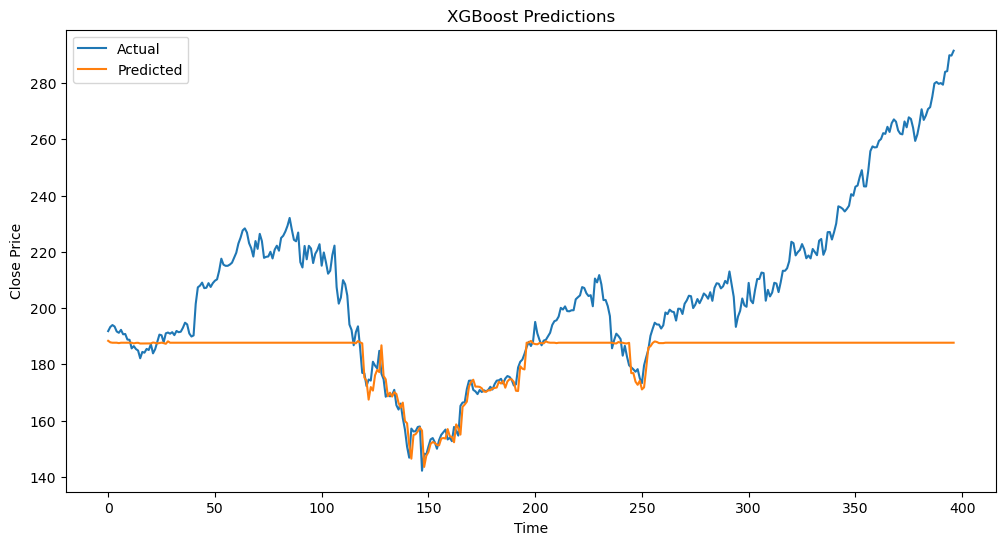

In [56]:
# plotting actual vs. predicted
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')

plt.plot(y_pred_xgb, label='Predicted')

plt.title('XGBoost Predictions')

plt.xlabel('Time')

plt.ylabel('Close Price')

plt.legend()

plt.show()

In [57]:
# feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_xgb)

  Feature  Importance
0   Lag_1    0.645819
4    MA_7    0.271247
1   Lag_2    0.056166
2   Lag_3    0.021231
3   Lag_7    0.005162
5   MA_30    0.000376


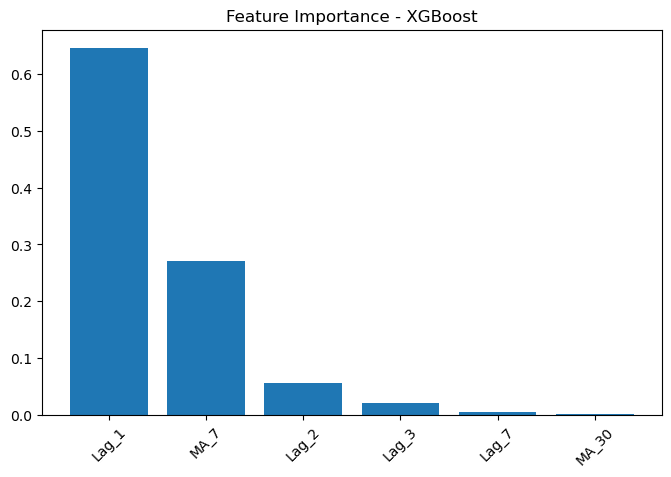

In [58]:
# plot feature importance
plt.figure(figsize=(8,5))

plt.bar(feature_importance_xgb['Feature'],
        feature_importance_xgb['Importance'])

plt.title('Feature Importance - XGBoost')

plt.xticks(rotation=45)

plt.show()

**Note:** Despite using more advanced machine learning models such as Random Forest and XGBoost, Linear Regression achieved the best performance. This suggests that Apple's stock prices exhibit a strong linear relationship with recent historical prices, making a simple linear model highly effective for forecasting.

**4. ARIMA Model**

In [69]:
# train-test split
train_size = int(len(df) * 0.8)

train = df['Close'][:train_size]
test = df['Close'][train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 1608
Test Size: 403


In [70]:
# building model
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1608
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3083.633
Date:                Wed, 17 Jun 2026   AIC                           6173.265
Time:                        15:26:29   BIC                           6189.412
Sample:                             0   HQIC                          6179.260
                               - 1608                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2829      0.404     -0.701      0.483      -1.074       0.508
ma.L1          0.3285      0.400      0.822      0.411      -0.455       1.111
sigma2         2.7179      0.056     48.115      0.0

In [71]:
# Forecast on Test Data
forecast_arima = arima_fit.forecast(steps=len(test))

C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [72]:
# convert to series
forecast_arima = arima_fit.forecast(steps=len(test)).values

forecast_arima = pd.Series(
    forecast_arima,
    index=test.index
)

C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [73]:
print(forecast_arima.isna().sum())

0


In [74]:
# Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae_arima = mean_absolute_error(test, forecast_arima)

rmse_arima = np.sqrt(
    mean_squared_error(test, forecast_arima)
)

mape_arima = (
    mean_absolute_percentage_error(
        test,
        forecast_arima
    ) * 100
)

r2_arima = r2_score(
    test,
    forecast_arima
)

print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)
print("R²  :", r2_arima)

MAE : 25.38674642985603
RMSE: 34.03428749377502
MAPE: 11.668423066944767
R²  : -0.2891438525038226


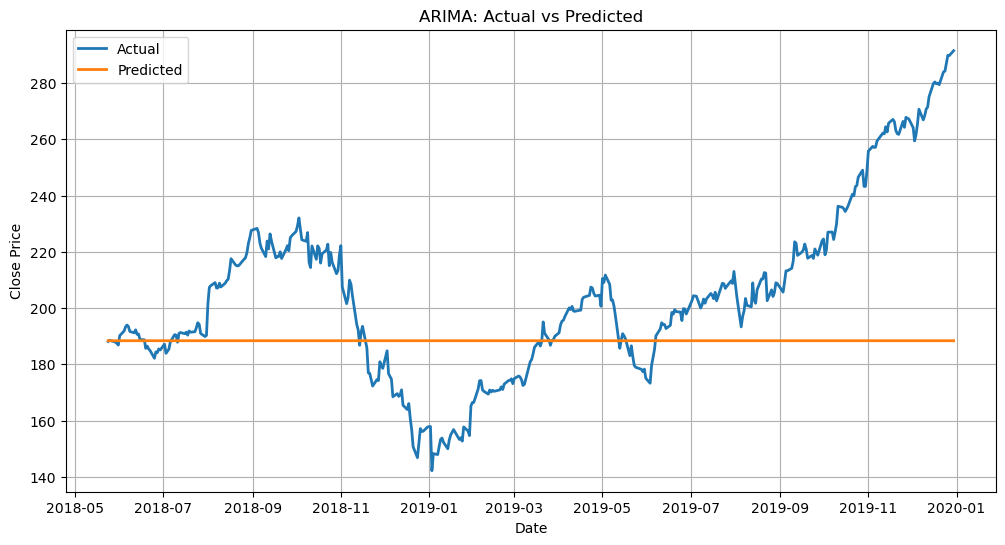

In [75]:
# plot Actual vs. predicted

plt.figure(figsize=(12,6))

plt.plot(test.index, test,
         label='Actual',
         linewidth=2)

plt.plot(test.index, forecast_arima,
         label='Predicted',
         linewidth=2)

plt.title('ARIMA: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.show()

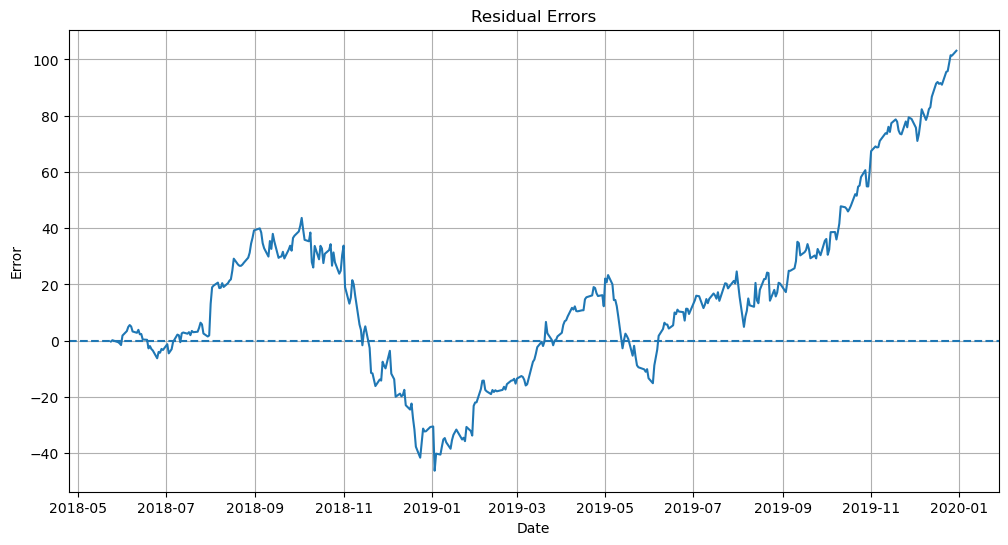

In [76]:
# plot residual errors
residuals = test - forecast_arima

plt.figure(figsize=(12,6))

plt.plot(residuals)

plt.title('Residual Errors')
plt.xlabel('Date')
plt.ylabel('Error')

plt.axhline(y=0, linestyle='--')
plt.grid(True)

plt.show()

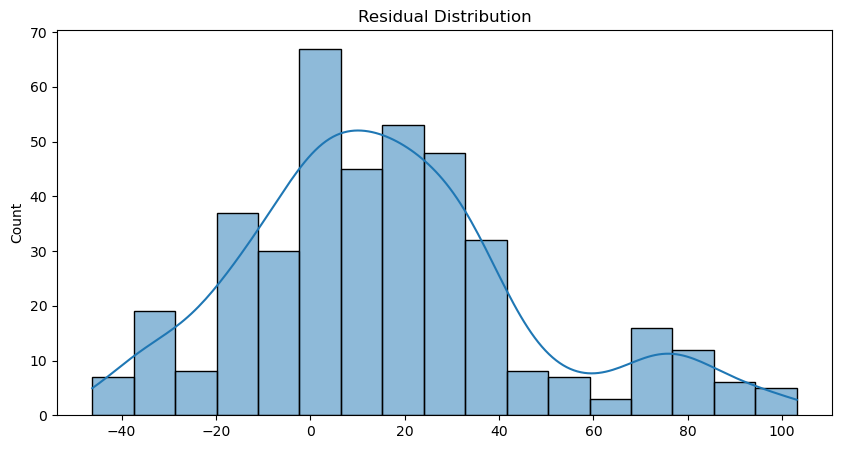

In [77]:
# distribution of residuals

plt.figure(figsize=(10,5))

sns.histplot(residuals,
             kde=True)

plt.title("Residual Distribution")

plt.show()

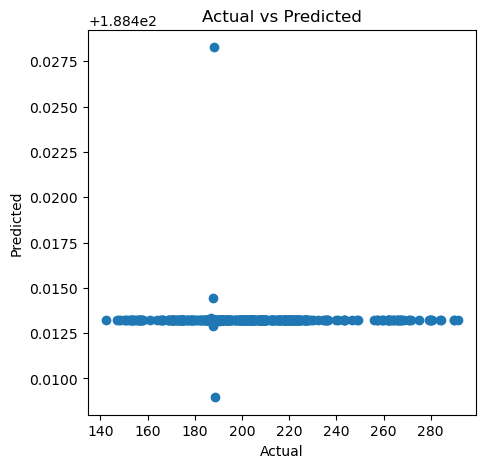

In [79]:
# Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(5,5))

plt.scatter(test,
            forecast_arima)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

**Note:** ARIMA(1,1,1) was implemented as a baseline forecasting model. The model produced nearly constant forecasts around 188.41 and failed to capture the fluctuations in stock prices. The negative R² score (-0.289) indicates that the model performed worse than a simple mean-based prediction. Therefore, more advanced models such as SARIMA were explored to improve forecasting accuracy.

In [84]:
# save forcast result
results = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast_arima
})

print(results.head())
results.to_csv('arima_predictions.csv')

                Actual   Predicted
Date                              
2018-05-24  188.149994  188.428281
2018-05-25  188.580002  188.408967
2018-05-29  187.899994  188.414430
2018-05-30  187.500000  188.412885
2018-05-31  186.869995  188.413322


In [85]:
# forcast future values
future_forecast = arima_fit.forecast(steps=30)

print(future_forecast)

1608    188.428281
1609    188.408967
1610    188.414430
1611    188.412885
1612    188.413322
1613    188.413198
1614    188.413233
1615    188.413223
1616    188.413226
1617    188.413225
1618    188.413225
1619    188.413225
1620    188.413225
1621    188.413225
1622    188.413225
1623    188.413225
1624    188.413225
1625    188.413225
1626    188.413225
1627    188.413225
1628    188.413225
1629    188.413225
1630    188.413225
1631    188.413225
1632    188.413225
1633    188.413225
1634    188.413225
1635    188.413225
1636    188.413225
1637    188.413225
Name: predicted_mean, dtype: float64


C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


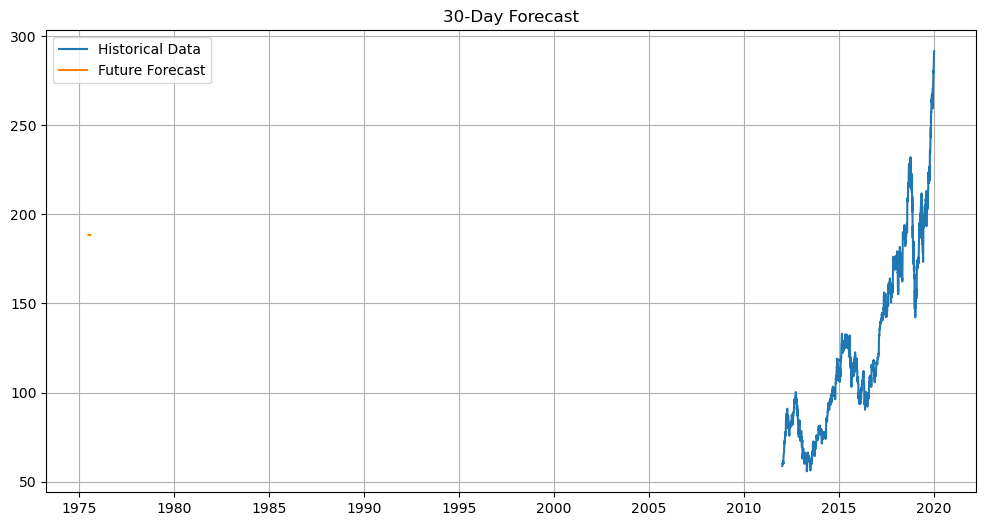

In [86]:
# plot future forecast
plt.figure(figsize=(12,6))

plt.plot(df['Close'],
         label='Historical Data')

plt.plot(
    range(len(df), len(df)+30),
    future_forecast,
    label='Future Forecast'
)

plt.title('30-Day Forecast')
plt.legend()
plt.grid(True)

plt.show()

**5. SARIMA Model**

In [87]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [88]:
# model building
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 1608
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3090.195
Date:                            Wed, 17 Jun 2026   AIC                           6190.389
Time:                                    15:49:56   BIC                           6217.262
Sample:                                         0   HQIC                          6200.370
                                           - 1608                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2809      0.451     -0.623      0.534      -1.165       0.604
ma.L1          0.3228      0.447   

In [89]:
# forecast test data
forecast_sarima = sarima_fit.forecast(
    steps=len(test)
)

forecast_sarima = pd.Series(
    forecast_sarima.values,
    index=test.index
)

C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [90]:
# check for NaN
print(forecast_sarima.isna().sum())

0


In [91]:
# evaluate model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

mae_sarima = mean_absolute_error(
    test,
    forecast_sarima
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        forecast_sarima
    )
)

mape_sarima = (
    mean_absolute_percentage_error(
        test,
        forecast_sarima
    )
    * 100
)

r2_sarima = r2_score(
    test,
    forecast_sarima
)

print("MAE :", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima)
print("R²  :", r2_sarima)

MAE : 20.788426812776468
RMSE: 26.345759090043956
MAPE: 10.351801926380537
R²  : 0.22751600830554852


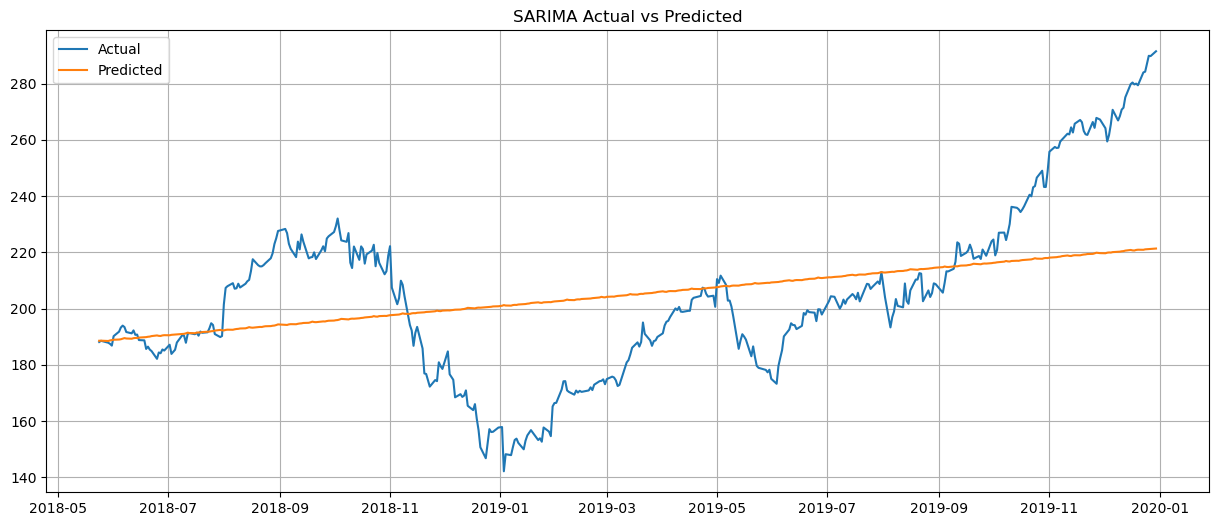

In [92]:
# actual vs. predicted plot
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    forecast_sarima,
    label='Predicted'
)

plt.title('SARIMA Actual vs Predicted')

plt.legend()

plt.grid(True)

plt.show()

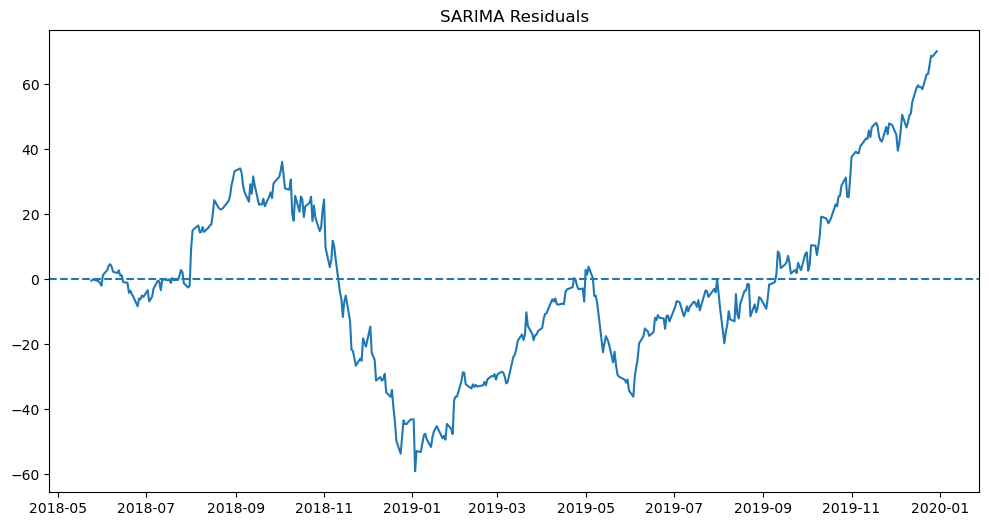

In [93]:
# residual plot
residuals_sarima = test - forecast_sarima

plt.figure(figsize=(12,6))

plt.plot(residuals_sarima)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(
    'SARIMA Residuals'
)

plt.show()

In [94]:
#save result
sarima_results = pd.DataFrame({
    'Actual': test,
    'Predicted': forecast_sarima
})

sarima_results.to_csv(
    'sarima_predictions.csv'
)

In [95]:
# future forcasting
future_forecast_sarima = (
    sarima_fit.forecast(
        steps=30
    )
)

print(
    future_forecast_sarima
)

1608    188.595739
1609    188.620979
1610    188.512610
1611    188.717507
1612    188.845365
1613    188.955064
1614    189.032887
1615    189.135007
1616    189.341543
1617    189.539592
1618    189.401590
1619    189.318261
1620    189.514221
1621    189.596243
1622    189.569724
1623    189.724560
1624    189.834409
1625    189.887702
1626    190.017114
1627    190.079116
1628    190.258118
1629    190.491010
1630    190.342698
1631    190.299223
1632    190.496418
1633    190.576676
1634    190.547616
1635    190.704006
1636    190.814415
1637    190.869459
Name: predicted_mean, dtype: float64


C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\91996\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


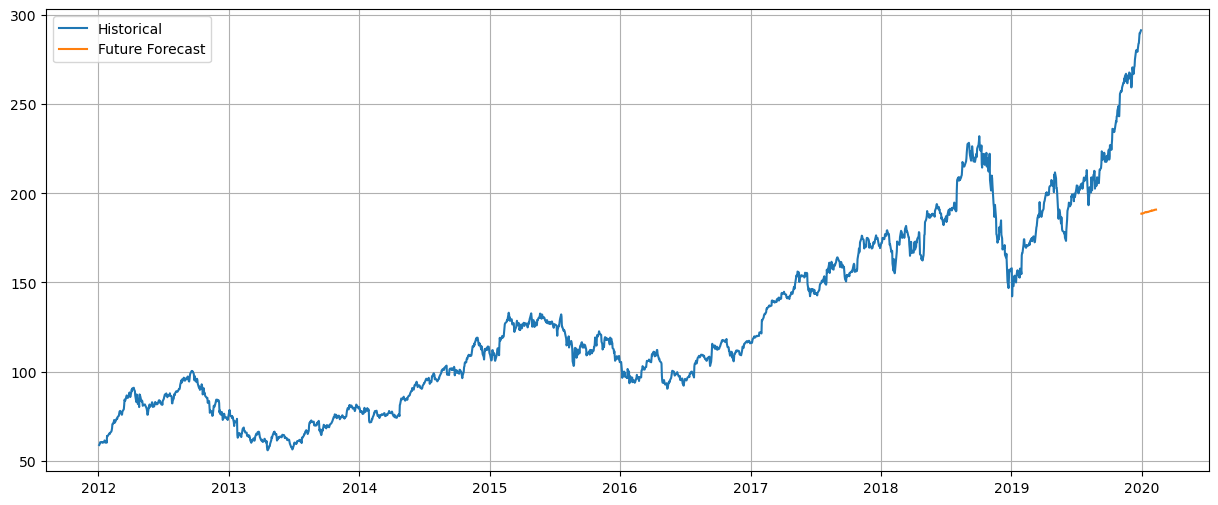

In [96]:
#future forecast plot
plt.figure(figsize=(15,6))

plt.plot(
    df['Close'],
    label='Historical'
)

future_index = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]

plt.plot(
    future_index,
    future_forecast_sarima,
    label='Future Forecast'
)

plt.legend()

plt.grid(True)

plt.show()

# **Stage 6: Model comparison table**

In [97]:
comparison = pd.DataFrame({
    'Model': ['lr', 'rf', 'xgb', 'ARIMA', 'SARIMA'],
    'MAE': [
        
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_arima,
        mae_sarima
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_arima,
        rmse_sarima
    ],
    'MAPE': [
        mape_lr,
        mape_rf,
        mape_xgb,
        mape_arima,
        mape_sarima
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_xgb,
        r2_arima,
        r2_sarima
    ]
})

print(comparison)

    Model        MAE       RMSE       MAPE        R2
0      lr   2.281670   3.095701   1.144268  0.989446
1      rf  21.521919  32.290075   9.258611 -0.148288
2     xgb  22.370956  33.046055   9.654286 -0.202685
3   ARIMA  25.386746  34.034287  11.668423 -0.289144
4  SARIMA  20.788427  26.345759  10.351802  0.227516


In [98]:
#save result
comparison.to_csv("model_comparison.csv", index=False)

In [99]:
#best for MAE:

best_mae = comparison.loc[comparison['MAE'].idxmin()]
print("Best MAE Model:")
print(best_mae)


Best MAE Model:
Model          lr
MAE       2.28167
RMSE     3.095701
MAPE     1.144268
R2       0.989446
Name: 0, dtype: object


In [100]:
#best for RMSE:

best_rmse = comparison.loc[comparison['RMSE'].idxmin()]
print("Best RMSE Model:")
print(best_rmse)


Best RMSE Model:
Model          lr
MAE       2.28167
RMSE     3.095701
MAPE     1.144268
R2       0.989446
Name: 0, dtype: object


In [101]:
#best for R²:

best_r2 = comparison.loc[comparison['R2'].idxmax()]
print("Best R2 Model:")
print(best_r2)


Best R2 Model:
Model          lr
MAE       2.28167
RMSE     3.095701
MAPE     1.144268
R2       0.989446
Name: 0, dtype: object


 **Final Project Conclusion** 

After seeing the comparison table:

Five forecasting models were implemented and evaluated using MAE, RMSE, MAPE, and R² metrics. Among all models, Linear Regression achieved the lowest prediction error and highest R² score, indicating superior forecasting performance. Therefore, Linear Regression was selected as the final model for stock price prediction.

# **Stage 7: Final 30 days forecasting** 

In [104]:
print(X.columns)
print(X_train.shape)

Index(['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'MA_7', 'MA_30'], dtype='object')
(1585, 6)


In [105]:
history = list(df['Close'])

future_predictions = []

for i in range(30):

    lag_1 = history[-1]
    lag_2 = history[-2]
    lag_3 = history[-3]
    lag_7 = history[-7]

    ma_7 = np.mean(history[-7:])
    ma_30 = np.mean(history[-30:])

    X_future = pd.DataFrame({
        'Lag_1': [lag_1],
        'Lag_2': [lag_2],
        'Lag_3': [lag_3],
        'Lag_7': [lag_7],
        'MA_7': [ma_7],
        'MA_30': [ma_30]
    })

    pred = lr.predict(X_future)[0]

    future_predictions.append(pred)

    history.append(pred)

future_df = pd.DataFrame({
    'Day': range(1, 31),
    'Predicted_Close': future_predictions
})

print(future_df)

    Day  Predicted_Close
0     1       288.743787
1     2       287.936753
2     3       287.555605
3     4       288.931317
4     5       289.623920
5     6       289.949719
6     7       289.156677
7     8       288.601122
8     9       288.445932
9    10       288.915511
10   11       289.360575
11   12       289.537266
12   13       289.318972
13   14       289.075508
14   15       289.019316
15   16       289.218782
16   17       289.471901
17   18       289.614061
18   19       289.593456
19   20       289.528051
20   21       289.533509
21   22       289.647506
22   23       289.802827
23   24       289.919465
24   25       289.967336
25   26       289.985552
26   27       290.026491
27   28       290.113306
28   29       290.222317
29   30       290.318385


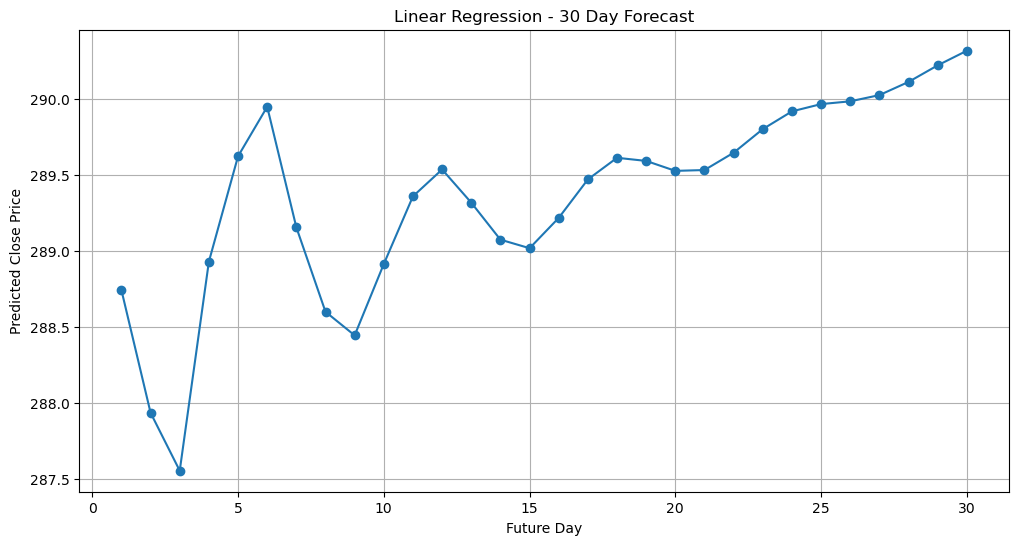

In [106]:
#plot forecasting
plt.figure(figsize=(12,6))

plt.plot(
    range(1,31),
    future_predictions,
    marker='o'
)

plt.title("Linear Regression - 30 Day Forecast")
plt.xlabel("Future Day")
plt.ylabel("Predicted Close Price")

plt.grid(True)
plt.show()

In [107]:
# save result
future_df.to_csv(
    "LinearRegression_30Day_Forecast.csv",
    index=False
)

**Final result:** Five machine learning and time-series forecasting models were developed and evaluated for stock price prediction. Based on MAE, RMSE, MAPE, and R² metrics, Linear Regression achieved the best overall performance and was selected as the final model. Future stock prices for the next 30 days were predicted using the trained Linear Regression model.

# **Stage 8: Model Deployment**

In [115]:
import pickle

with open("apple_stock_model.pkl", "wb") as f:
    pickle.dump(lr, f)

print("Model Saved Successfully!")

Model Saved Successfully!


In [113]:
df_ml.to_csv("apple_stock_data.csv", index=False)

In [114]:
import pickle

feature_columns = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_7',
    'MA_7',
    'MA_30'
]

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)